In [1]:
%cd ..

/home/hsc/Projects/personal/disertation


In [2]:
from pathlib import Path


DATA_DIRPATH = Path("./data")
PROJECT_DIRPATH = Path("./iterations")
TRAIN_DATA_DIRPATH = DATA_DIRPATH / "train"
TEST_DATA_DIRPATH = DATA_DIRPATH / "test"
TRAIN_CSV_FILEPATH = DATA_DIRPATH / "train_labels.csv"
THRESH_CSV_FILEPATH = DATA_DIRPATH / "train_thresholds.csv"

In [3]:
import torch
DEVICE = torch.device("cuda:0")

In [4]:
import dataclasses
import os

import numpy as np
import pandas as pd


@dataclasses.dataclass
class Prediction:
    image_id: (
        str | None
    )  # A unique identifier for the row -- unused otherwise. Used only on the hidden test set.
    dataset: str
    filename: str
    image_filepath: Path
    cluster_index: int | None = None
    rotation: np.ndarray | None = None
    translation: np.ndarray | None = None


# Set is_train=True to run the notebook on the training data.
# Set is_train=False if submitting an entry to the competition (test data is hidden, and different from what you see on the "test" folder).
is_train = True
data_dir = DATA_DIRPATH
workdir = PROJECT_DIRPATH
os.makedirs(workdir, exist_ok=True)

if is_train:
    sample_submission_csv = DATA_DIRPATH / "train_labels.csv"
    df = pd.read_csv(sample_submission_csv)
    df["image_id"] = df.dataset + "_" + df.image
    DATASET_DIR = TRAIN_DATA_DIRPATH
else:
    sample_submission_csv = DATA_DIRPATH / "sample_submission.csv"
    df = pd.read_csv(sample_submission_csv)
    DATASET_DIR = TEST_DATA_DIRPATH

samples = {}
for _, row in df.iterrows():
    # Note: For the test data, the "scene" column has no meaning, and the rotation_matrix and translation_vector columns are random.
    if row.dataset not in samples:
        samples[row.dataset] = []
    samples[row.dataset].append(
        Prediction(
            image_id=row.image_id,
            dataset=row.dataset,
            filename=row.image,
            image_filepath=DATASET_DIR / row.dataset / row.image,
        )
    )

for dataset in samples:
    print(f'Dataset "{dataset}" -> num_images={len(samples[dataset])}')

Dataset "imc2023_haiper" -> num_images=54
Dataset "imc2023_heritage" -> num_images=209
Dataset "imc2023_theather_imc2024_church" -> num_images=76
Dataset "imc2024_dioscuri_baalshamin" -> num_images=138
Dataset "imc2024_lizard_pond" -> num_images=214
Dataset "pt_brandenburg_british_buckingham" -> num_images=225
Dataset "pt_piazzasanmarco_grandplace" -> num_images=168
Dataset "pt_sacrecoeur_trevi_tajmahal" -> num_images=225
Dataset "pt_stpeters_stpauls" -> num_images=200
Dataset "amy_gardens" -> num_images=200
Dataset "fbk_vineyard" -> num_images=163
Dataset "ETs" -> num_images=22
Dataset "stairs" -> num_images=51


In [5]:
predictions = samples["imc2023_haiper"]

In [6]:
from mts.pipeline.repository.inmemeory import ImageRepository

image_repository = ImageRepository()

In [7]:
from mts.core.extractor.aliked import AlikedExtractor


aliked = AlikedExtractor(1024, 1024)

In [8]:
for pred in predictions:
    image_repository.add_image(pred.image_filepath)

In [9]:
import torch


CUDA0 = torch.device("cuda:0")

In [10]:
from mts.core.embedder.dinov2 import DinoV2GlobalDescriptors


dino_v2 = DinoV2GlobalDescriptors.from_pretrained("weights/dinov2/base")

/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [11]:
from mts.pipeline.step.extract.kp.base import TorchExtractStep


extract_step = TorchExtractStep(image_repository, aliked)
extract_step = extract_step.to(DEVICE)

In [12]:
from mts.pipeline.step.extract.embedding.base import GlobalDescriptorStep

global_extractor_step = GlobalDescriptorStep(image_repository, dino_v2)
global_extractor_step = global_extractor_step.to(DEVICE)

In [13]:
with torch.no_grad():
    extract_step.run()

Extract keypoints and descriptors:   0%|          | 0/54 [00:00<?, ?it/s]

Extract keypoints and descriptors: 100%|██████████| 54/54 [00:10<00:00,  5.12it/s]


In [14]:
with torch.no_grad():
    global_extractor_step.run()

Extract keypoints and descriptors:   0%|          | 0/54 [00:00<?, ?it/s]

Extract keypoints and descriptors: 100%|██████████| 54/54 [00:05<00:00,  9.49it/s]


In [15]:
from mts.pipeline.step.pair.cdist import CrossEmbeddingParer


parer = CrossEmbeddingParer(image_repository)

In [16]:
parer.run()

In [17]:
from mts.core.matcher.lg import LightGlueMatcher


lg_matcher = LightGlueMatcher.from_config(
    "aliked",
    {
        "width_confidence": -1,
        "depth_confidence": -1,
        "mp": True if "cuda" in str(DEVICE) else False,
    },
)
lg_matcher = lg_matcher.to(CUDA0)

Loaded LightGlue model


In [18]:
from mts.pipeline.step.match.base import MatchingStep


matching_step = MatchingStep(image_repository, lg_matcher)
matching_step = matching_step.to(DEVICE)

In [19]:
with torch.no_grad():
    matching_step.run()

  0%|          | 0/1431 [00:00<?, ?it/s]

100%|██████████| 1431/1431 [00:32<00:00, 44.06it/s]


In [56]:
image_repository.pair_num()

1431

In [58]:
image_repository.get_matches(0, 1)

array([[   0,  104],
       [  17,  666],
       [  28,  891],
       [  31,   53],
       [  40,  879],
       [  57,  986],
       [  61,   35],
       [  67,    1],
       [  69,  318],
       [  75,  183],
       [  79,    0],
       [  81,  849],
       [  82,   11],
       [  86,  222],
       [  88,  293],
       [  91,  933],
       [  94,   85],
       [  97,  372],
       [  99,   63],
       [ 101,   67],
       [ 108,  525],
       [ 118,  279],
       [ 122,  449],
       [ 124,  811],
       [ 128,  640],
       [ 145,  274],
       [ 159,  900],
       [ 163,  459],
       [ 168,  300],
       [ 178,  512],
       [ 179,  510],
       [ 180,  870],
       [ 185,  587],
       [ 191,  830],
       [ 196,  617],
       [ 208,  611],
       [ 215,  465],
       [ 216,   15],
       [ 220,  880],
       [ 245,  819],
       [ 246,  577],
       [ 249,  732],
       [ 251,  912],
       [ 263,  395],
       [ 267,  450],
       [ 275,   33],
       [ 279,  526],
       [ 282,

In [57]:
image_repository.get_pairs()

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (0, 42),
 (0, 43),
 (0, 44),
 (0, 45),
 (0, 46),
 (0, 47),
 (0, 48),
 (0, 49),
 (0, 50),
 (0, 51),
 (0, 52),
 (0, 53),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (1, 42),
 (1, 43),
 (1, 44),
 (1, 45),
 (1, 46),
 (1, 47),
 (1, 48),
 (1, 49),
 (1, 50

In [20]:
import more_itertools as mit
import itertools as it

In [21]:
import hloc

In [25]:
from mts.helpers.colmap.database import COLMAPDatabase

In [ ]:
from mts.pipeline.step.reconstruct.colmap.importt import ColmapImportStep


colmap_import_step = ColmapImportStep.from_directory("iterations/test", image_repository)

In [65]:
colmap_import_step.run()

Add matches: 100%|██████████| 1431/1431 [00:00<00:00, 162877.86it/s]


In [22]:
from hloc.utils import viz as img_viz

In [23]:
import kornia.feature as KF

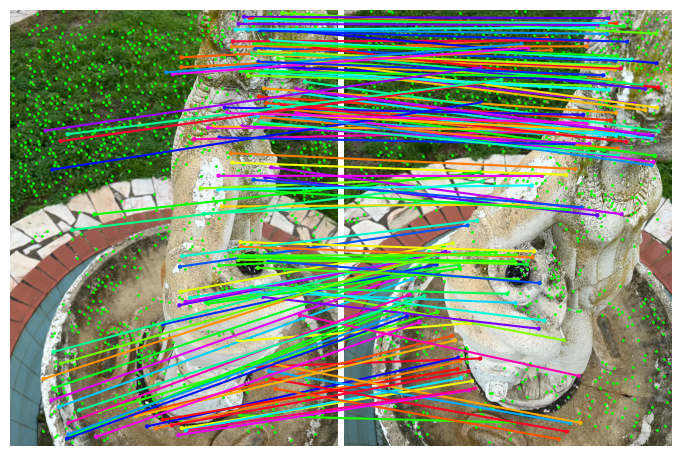

In [24]:
img_viz.plot_images([image_repository.load_image(0), image_repository.load_image(1)])
st_kp = image_repository.get_keypoints(0)
nd_kp = image_repository.get_keypoints(1)

img_viz.plot_keypoints([st_kp, nd_kp])
matches = image_repository.get_matches(0, 1)
img_viz.plot_matches(st_kp[matches[:, 0]], nd_kp[matches[:, 1]])